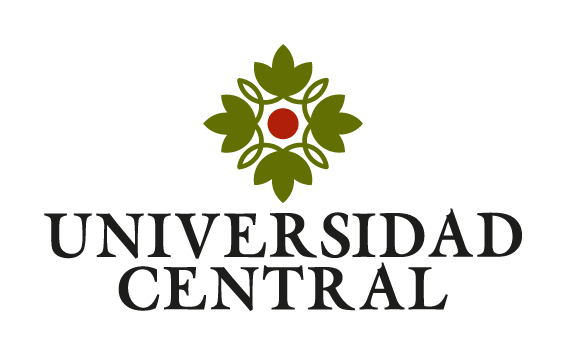

#MAESTRIA EN ANALITICA DE DATOS
---

PROCESAMIENTO DEL LENGUAJE NATURAL

Nombre: Oswaldo Salgado Gómez

Fecha: mayo 16 de 2026

Taller: Trabajo Final

# Etapa 1B. Generación de Archivos JSON — Autos de Apertura ANLA

**Etapa 1B — Captura y Preparación de Datos** del prototipo RAG-jurimétrico.

Este notebook convierte los PDFs de autos de inicio de procedimiento sancionatorio
ambiental de la ANLA en un JSON estructurado, listo para:

- Almacenamiento en **MongoDB** (texto completo + metadata).
- Segmentación inteligente (Stage 2) en *chunks* de 2.048 tokens con 20% de solapamiento.
- Indexación por embeddings (TF-IDF / RoBERTa / Longformer) → ChromaDB (Stage 3).
- Recuperación + generación con Llama / Mistral (Stage 4) y Dashboard Jurimétrico.


# HOJA DE RUTA A SEGUIR

0.  Montar Google Drive
1.  Instalar Dependencias
2.  Instalar Librerías
3.  Configuración de Rutas
4.  Pipeline con Fixes Integrados
5.  Pipeline de Segmentación y Limpieza
6.  Procesamiento Batch
7.  Validación
8.  Inspección de un Documento



# 0\. Montar Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# 1\. Instalar Dependencias



In [ ]:
!apt-get -qq install -y poppler-utils tesseract-ocr tesseract-ocr-spa > /dev/null
!pip install -q 'unstructured[pdf]' pandas pydantic lxml html5lib beautifulsoup4 pdfminer.six tabulate tqdm pdfplumber


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.1/543.1 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.8/453.8 kB 23.6 MB/s eta 0:00:00

#2\. Instalar Librerías


In [ ]:
import os
import json
import re
import uuid
import time
import warnings
from io import StringIO
from datetime import datetime
from collections import Counter
from typing import List, Optional, Dict, Tuple
from pathlib import Path

import pandas as pd
import pdfplumber
from pydantic import BaseModel, Field
from unstructured.partition.pdf import partition_pdf
from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=FutureWarning)
print('✅ Imports OK')


✅ Imports OK


#3\. Configuración de Rutas


In [ ]:
INPUT_DIR  = '/content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Actos_Apertura_pdf/pdf_debug_5'
OUTPUT_DIR = '/content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Autos_Apertura_Json/v4_5pdfs'

if not os.path.exists(INPUT_DIR):
    raise FileNotFoundError(f'❌ No existe: {INPUT_DIR}')

os.makedirs(OUTPUT_DIR, exist_ok=True)

archivos = sorted(f for f in os.listdir(INPUT_DIR) if f.lower().endswith('.pdf'))
print(f'📂 Entrada  : {INPUT_DIR}')
print(f'📂 Salida   : {OUTPUT_DIR}')
print(f'📄 PDFs     : {len(archivos)}')


📂 Entrada  : /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Actos_Apertura_pdf/pdf_debug_5
📂 Salida   : /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Autos_Apertura_Json/v4_5pdfs
📄 PDFs     : 5


#4\. Pipeline con fixes integrados

- FIX 1: Regex OCR-tolerante para tipo/número
- FIX 2: Búsqueda de fecha por proximidad
- FIX 3: Empresa por frecuencia ponderada
- FIX 4: Sección romana I/l tolerante
- FIX 5: Municipio sin overcapture
- FIX 6: Fallback pdfplumber para tablas


In [ ]:
# Modelos Pydantic
class ElementoTabular(BaseModel):
    id: str
    seccion: Optional[str] = None
    titulo: Optional[str] = None
    markdown: str
    fuente: str  # 'html' | 'texto_plano' | 'pdfplumber'
    dimensiones: Dict[str, int] = Field(default_factory=dict)
    pagina: Optional[int] = None


class Bloque(BaseModel):
    id: str
    numeral: Optional[str] = None
    tipo_numeral: Optional[str] = None
    nivel: int = 0
    titulo: Optional[str] = None
    texto: str = ''
    pagina_inicio: Optional[int] = None
    pagina_fin: Optional[int] = None
    tablas_anidadas: List[ElementoTabular] = Field(default_factory=list)


class Documento(BaseModel):
    id_documento: str
    filename: str
    tipo_documento: Optional[str] = None
    numero_documento: Optional[str] = None
    fecha_documento: Optional[str] = None
    expediente_sancionatorio: Optional[str] = None
    expediente_permisivo: Optional[str] = None
    empresa: Optional[str] = None
    nit_investigado: Optional[str] = None
    proyecto: Optional[str] = None
    municipio: Optional[str] = None
    ubicacion: Optional[str] = None
    bloques: List[Bloque] = Field(default_factory=list)
    tablas: List[ElementoTabular] = Field(default_factory=list)
    metadata: Dict = Field(default_factory=dict)


MESES = {
    'enero': '01', 'febrero': '02', 'marzo': '03', 'abril': '04',
    'mayo': '05', 'junio': '06', 'julio': '07', 'agosto': '08',
    'septiembre': '09', 'setiembre': '09', 'octubre': '10',
    'noviembre': '11', 'diciembre': '12',
}
MESES_ABREV = {
    'ENE': '01', 'FEB': '02', 'MAR': '03', 'ABR': '04', 'MAY': '05', 'JUN': '06',
    'JUL': '07', 'AGO': '08', 'SEP': '09', 'OCT': '10', 'NOV': '11', 'DIC': '12',
}
EMPRESAS_HISTORICAS = {'Ecopetrol', 'Ecogás', 'Colombiana de Gas', 'ECOPETROL', 'ECOGAS'}

print('✅ Modelos cargados')


✅ Modelos cargados


#5\. Pipeline de Segmentación y Limpieza

In [ ]:
class ANLAPipelineV4:
    def __init__(self, verbose: bool = False):
        self.verbose = verbose
        self._compilar_patrones()

    def _compilar_patrones(self):
        self.patterns = {
            "considerando": re.compile(r"^CONSIDERANDO(?:\s+QUE)?[:.]\s*$", re.IGNORECASE),
            "dispone": re.compile(r"^(DISPONE|RESUELVE)[:.]\s*$", re.IGNORECASE),
            "seccion_romana": re.compile(
                r"^([IVXivxl]{1,4}|l)\.\s+(Competencia|Antecedentes|Caso\s+concreto|"
                r"Incumplimiento|Presunto\s+incumplimiento|"
                r"Incorporacion\s+de\s+[Dd]ocumentos)(.*)",
                re.IGNORECASE),
            "hecho": re.compile(
                r"^HECHO\s+(UNICO|PRIMERO|SEGUNDO|TERCERO|\d+)[:.]\s*(.*)",
                re.IGNORECASE),
            "articulo_ordinal": re.compile(
                r"^ARTICULO\s+(PRIMERO|SEGUNDO|TERCERO|CUARTO|QUINTO|SEXTO|"
                r"SEPTIMO|OCTAVO|NOVENO|DECIMO)[:.]\s*(.*)",
                re.IGNORECASE),
            "articulo_num": re.compile(r"^ARTICULO\s+(\d+|[IVXLC]+)[:.]\s*(.*)", re.IGNORECASE),
            "requerimiento": re.compile(
                r"^REQUERIMIENTO\s+(?:N[°ºo.\\*]?\s*)?(\d+)[:.]\s*(.*)",
                re.IGNORECASE),
            "subnumeral": re.compile(r"^(\d+\.\d+(?:\.\d+)*)\.\s+(.*)"),
            "simple": re.compile(r"^(\d+)\.\s+(.*)"),
            "literal": re.compile(r"^([a-z])[.)]\s*(.+)", re.IGNORECASE),
        }

    def detectar_numeral(self, texto: str) -> Optional[Dict]:
        texto = texto.strip()
        if not texto:
            return None

        for pattern_name, tipo, nivel, label in [
            ("considerando", "considerando", 0, "CONSIDERANDO"),
            ("dispone", "dispone", 0, None),
            ("seccion_romana", "seccion", 1, None),
            ("hecho", "hecho", 1, None),
            ("articulo_ordinal", "articulo_ordinal", 1, None),
            ("articulo_num", "articulo", 1, None),
            ("requerimiento", "requerimiento", 1, None),
            ("subnumeral", "subnumeral", None, None),
            ("simple", "simple", 1, None),
            ("literal", "literal", 2, None),
        ]:
            m = self.patterns[pattern_name].match(texto)
            if not m:
                continue

            if pattern_name == "considerando":
                return {"numeral": "CONSIDERANDO", "tipo_numeral": tipo,
                        "nivel": 0, "titulo": "CONSIDERANDO"}
            if pattern_name == "dispone":
                kw = m.group(1).upper()
                return {"numeral": kw, "tipo_numeral": tipo, "nivel": 0, "titulo": kw}
            if pattern_name == "seccion_romana":
                sec = m.group(1).upper().replace("L", "I")  # FIX 4
                return {"numeral": f"SEC_{sec}", "tipo_numeral": tipo, "nivel": 1,
                        "titulo": (m.group(2) + (m.group(3) or "")).strip()}
            if pattern_name == "hecho":
                return {"numeral": f"HECHO_{m.group(1).upper()}", "tipo_numeral": tipo,
                        "nivel": 1, "titulo": m.group(2).strip()}
            if pattern_name == "articulo_ordinal":
                ord_clean = re.sub(r"\s+", "_", m.group(1).upper())
                return {"numeral": f"ART_{ord_clean}", "tipo_numeral": tipo,
                        "nivel": 1, "titulo": m.group(2).strip()}
            if pattern_name == "articulo_num":
                return {"numeral": f"ART_{m.group(1)}", "tipo_numeral": tipo,
                        "nivel": 1, "titulo": m.group(2).strip()}
            if pattern_name == "requerimiento":
                return {"numeral": f"REQ_{m.group(1)}", "tipo_numeral": tipo,
                        "nivel": 1, "titulo": m.group(2).strip()}
            if pattern_name == "subnumeral":
                nivel = m.group(1).count(".") + 1
                return {"numeral": m.group(1), "tipo_numeral": tipo, "nivel": nivel,
                        "titulo": m.group(2).strip()}
            if pattern_name == "simple":
                return {"numeral": m.group(1), "tipo_numeral": tipo, "nivel": 1,
                        "titulo": m.group(2).strip()}
            if pattern_name == "literal":
                return {"numeral": m.group(1).lower(), "tipo_numeral": tipo,
                        "nivel": 2, "titulo": m.group(2).strip()}

        return None

    def extraer_metadatos(self, texto: str, path_pdf: str = "") -> Dict:
        meta = {}

        # FIX 1: OCR-tolerante (N° → N* → N.)
        m = re.search(r"(AUTO|RESOLUCION)\s+N[°º.\\*]?\s*(\d{3,6})",
                      texto, re.IGNORECASE)
        if m:
            meta["tipo_documento"] = m.group(1).upper()
            num = m.group(2).lstrip("0")
            meta["numero_documento"] = num if num else m.group(2)

        # FIX 2: Fecha con proximidad (DESPUÉS de AUTO N°)
        auto_pos = re.search(r"(AUTO|RESOLUCION)\s+N[°º.\\*]?\s*\d{3,6}",
                             texto, re.IGNORECASE)
        search_start = auto_pos.end() if auto_pos else 0
        search_region = texto[search_start:search_start+200]

        m = re.search(
            r"\(\s*(\d{1,2})\s+de\s+(enero|febrero|marzo|abril|mayo|junio|"
            r"julio|agosto|septiembre|setiembre|octubre|noviembre|diciembre)\s+"
            r"de\s+(\d{4})\s*\)", search_region, re.IGNORECASE)
        if m:
            meta["fecha_documento"] = (
                f"{m.group(3)}-{MESES[m.group(2).lower()]}-{int(m.group(1)):02d}")
        else:
            m = re.search(
                r"\(\s*(\d{1,2})\s+(ENE|FEB|MAR|ABR|MAY|JUN|JUL|AGO|SEP|OCT|"
                r"NOV|DIC)\.\s+(\d{4})\s*\)", search_region, re.IGNORECASE)
            if m:
                meta["fecha_documento"] = (
                    f"{m.group(3)}-{MESES_ABREV[m.group(2).upper()]}-"
                    f"{int(m.group(1)):02d}")

        # Expediente sancionatorio
        m = re.search(r"(SAN|DAA)\d{3,5}-\d{2}-\d{4}", texto)
        if m:
            meta["expediente_sancionatorio"] = m.group(0)

        # Expediente permisivo
        matches = re.findall(r"\b(LAM\d{3,5})\b", texto)
        if matches:
            meta["expediente_permisivo"] = Counter(matches).most_common(1)[0][0]

        # NIT
        m = re.search(
            r"NIT[:.]\s*(?:No\.)?\s*(\d{3}\.?\d{3}\.?\d{3}-\d)", texto)
        if m:
            meta["nit_investigado"] = m.group(1)

        # FIX 3: Empresa por frecuencia ponderada
        candidatos = re.findall(
            r"sociedad\s+([A-ZÁÉÍÓÚÑ][\wÁÉÍÓÚÑáéíóúñ\s.\-&,]{3,100}?)\s+"
            r"(S\.A\.S\.|S\.A\.|LTD|LLC|CORP|GMBH|S\s+en\s+C\.)", texto)
        if candidatos:
            cleaned = []
            for match in candidatos:
                if isinstance(match, tuple):
                    empresa_texto = match[0] + " " + match[1]
                else:
                    empresa_texto = match
                empresa_texto = re.sub(r"\s+", " ", empresa_texto).strip().rstrip(",.")
                cleaned.append(empresa_texto)

            freq = Counter(cleaned)
            for empresa in list(freq.keys()):
                for hist in EMPRESAS_HISTORICAS:
                    if hist.lower() in empresa.lower():
                        freq[empresa] = max(1, int(freq[empresa] * 0.5))
                        break
            if freq:
                meta["empresa"] = freq.most_common(1)[0][0]

        # Proyecto
        m = re.search(r'proyecto\s+["\']([^"\']{5,200})["\']', texto, re.IGNORECASE)
        if m:
            meta["proyecto"] = m.group(1).strip()

        # FIX 5: Municipio sin overcapture
        m = re.search(
            r"municipio\s+de\s+([A-ZÁÉÍÓÚÑ][a-záéíóúñ\s]{2,30}?)"
            r"(?=\s+(?:del\s+departamento|\(|,|del|\.|$))",
            texto, re.IGNORECASE)
        if m:
            meta["municipio"] = m.group(1).strip().title()

        return meta

    def tabla_a_markdown(self, html: Optional[str],
                        texto_fallback: str = "") -> Tuple[str, str, Dict[str, int]]:
        if html:
            try:
                dfs = pd.read_html(StringIO(html))
                if dfs:
                    df = dfs[0]
                    df = df.dropna(how="all").dropna(axis=1, how="all").fillna("")
                    df = df.astype(str).map(lambda s: re.sub(r"\s+", " ", s).strip())
                    df = df[~(df == "").all(axis=1)]
                    if len(df) > 0 and len(df.columns) > 0:
                        return (df.to_markdown(index=False), "html",
                                {"filas": len(df), "columnas": len(df.columns)})
            except Exception:
                pass

        texto = (texto_fallback or "").strip()
        if not texto:
            return "", "vacio", {}

        lineas = [l for l in texto.split("\n") if l.strip()]
        if len(lineas) >= 2:
            rows = [re.split(r"\s{2,}", l.strip()) for l in lineas]
            counts = Counter(len(r) for r in rows)
            n_cols = counts.most_common(1)[0][0] if counts else 0
            if n_cols >= 2:
                rows = [r for r in rows if len(r) == n_cols]
                if len(rows) >= 2:
                    md_lines = [
                        "| " + " | ".join(rows[0]) + " |",
                        "|" + "|".join(["---"] * n_cols) + "|",
                    ] + ["| " + " | ".join(r) + " |" for r in rows[1:]]
                    return ("\n".join(md_lines), "texto_plano",
                            {"filas": len(rows) - 1, "columnas": n_cols})

        return f"```\n{texto}\n```", "preformateado", {}

    def extraer_tablas_pdfplumber(self, path_pdf: str) -> List[Tuple[str, int, Dict]]:
        tablas = []
        try:
            with pdfplumber.open(path_pdf) as pdf:
                for page_num, page in enumerate(pdf.pages, 1):
                    page_tables = page.extract_tables()
                    if not page_tables:
                        continue
                    for table_data in page_tables:
                        if not table_data or len(table_data) < 2:
                            continue
                        df = pd.DataFrame(table_data[1:], columns=table_data[0])
                        df = df.fillna("")
                        df = df.astype(str).map(lambda s: re.sub(r"\s+", " ", s).strip())
                        df = df[~(df == "").all(axis=1)]
                        if len(df) > 0:
                            md = df.to_markdown(index=False)
                            dims = {"filas": len(df), "columnas": len(df.columns)}
                            tablas.append((md, page_num, dims))
        except Exception as e:
            if self.verbose:
                print(f"  ⚠️  pdfplumber error: {e}")
        return tablas

    def procesar_documento(self, path: str) -> Documento:
        if not os.path.exists(path):
            raise FileNotFoundError(path)

        elementos = partition_pdf(filename=path, strategy="hi_res",
                                 infer_table_structure=True, languages=["spa"])
        if not elementos:
            raise ValueError("PDF sin contenido")

        elementos_dict = []
        for el in elementos:
            try:
                d = el.to_dict()
            except Exception:
                d = {
                    "type": el.__class__.__name__,
                    "text": getattr(el, "text", "") or "",
                    "metadata": getattr(el, "metadata", None).to_dict()
                                if getattr(el, "metadata", None) else {},
                }
            elementos_dict.append(d)

        texto_completo = " ".join(d.get("text", "") for d in elementos_dict)
        meta = self.extraer_metadatos(texto_completo, path)

        tabla_positions = {}
        for idx, d in enumerate(elementos_dict):
            if d.get("type") != "Table":
                continue
            md_meta = d.get("metadata", {}) or {}
            html = md_meta.get("text_as_html")
            pagina = md_meta.get("page_number")
            md_text, fuente, dims = self.tabla_a_markdown(html, d.get("text", ""))
            if not md_text:
                continue
            tabla_positions[idx] = ElementoTabular(
                id=str(uuid.uuid4()), markdown=md_text, fuente=fuente,
                dimensiones=dims, pagina=pagina)

        # FIX 6: fallback pdfplumber
        if not tabla_positions:
            tablas_pdfplumber = self.extraer_tablas_pdfplumber(path)
            for md_text, pag, dims in tablas_pdfplumber:
                tabla_positions[f"pdfplumber_{pag}"] = ElementoTabular(
                    id=str(uuid.uuid4()), markdown=md_text, fuente="pdfplumber",
                    dimensiones=dims, pagina=pag)

        bloques = []
        actual = self._bloque_inicial()
        tablas_globales = []

        for idx, d in enumerate(elementos_dict):
            texto = re.sub(r"\s+", " ", (d.get("text") or "").strip())
            md_meta = d.get("metadata", {}) or {}
            pagina = md_meta.get("page_number")

            if idx in tabla_positions:
                tab = tabla_positions[idx]
                tab.seccion = actual.get("numeral")
                tab.titulo = (actual.get("titulo") or "")[:120] or None
                actual["tablas_anidadas"].append(tab)
                tablas_globales.append(tab)
                continue

            if not texto:
                continue

            numeral_info = self.detectar_numeral(texto)
            if numeral_info:
                if actual["texto"].strip() or actual["tablas_anidadas"]:
                    bloques.append(Bloque(**actual))
                actual = {
                    "id": str(uuid.uuid4()),
                    **numeral_info,
                    "texto": "",
                    "pagina_inicio": pagina,
                    "pagina_fin": pagina,
                    "tablas_anidadas": [],
                }
            else:
                actual["texto"] = (actual["texto"] + " " + texto).strip()
                if pagina is not None:
                    if actual.get("pagina_inicio") is None:
                        actual["pagina_inicio"] = pagina
                    actual["pagina_fin"] = pagina

        if actual["texto"].strip() or actual["tablas_anidadas"]:
            bloques.append(Bloque(**actual))

        doc = Documento(
            id_documento=str(uuid.uuid4()),
            filename=os.path.basename(path),
            tipo_documento=meta.get("tipo_documento"),
            numero_documento=meta.get("numero_documento"),
            fecha_documento=meta.get("fecha_documento"),
            expediente_sancionatorio=meta.get("expediente_sancionatorio"),
            expediente_permisivo=meta.get("expediente_permisivo"),
            empresa=meta.get("empresa"),
            nit_investigado=meta.get("nit_investigado"),
            proyecto=meta.get("proyecto"),
            municipio=meta.get("municipio"),
            bloques=bloques,
            tablas=tablas_globales,
            metadata={
                "pipeline": "ANLA_parser_v4",
                "fecha_procesamiento": datetime.now().isoformat(timespec="seconds"),
                "total_bloques": len(bloques),
                "total_tablas": len(tablas_globales),
                "elementos_procesados": len(elementos_dict),
                "tipos_elemento": dict(
                    Counter(d.get("type", "?") for d in elementos_dict)),
                "tablas_con_fallback_pdfplumber": len(
                    [t for t in tablas_globales if t.fuente == "pdfplumber"]),
            },
        )
        return doc

    @staticmethod
    def _bloque_inicial() -> Dict:
        return {
            "id": str(uuid.uuid4()),
            "numeral": "INTRO",
            "tipo_numeral": "intro",
            "nivel": 0,
            "titulo": "ENCABEZADO Y PROEMIO",
            "texto": "",
            "pagina_inicio": None,
            "pagina_fin": None,
            "tablas_anidadas": [],
        }

print("✅ Pipeline ANLAPipelineV4 cargado")

✅ Pipeline ANLAPipelineV4 cargado


# 6\. Procesamiento Batch


In [ ]:
pipeline = ANLAPipelineV4(verbose=False)
archivos = sorted(f for f in os.listdir(INPUT_DIR) if f.lower().endswith('.pdf'))
if not archivos:
    raise ValueError('❌ No hay PDFs')

print(f'📂 Total PDFs: {len(archivos)}\n')

resultados = {'exitosos': 0, 'errores': 0, 'saltados': 0, 'tiempo_total': 0.0}
errores_detalle = []

for archivo in tqdm(archivos, desc='Procesando PDFs'):
    ruta_in  = os.path.join(INPUT_DIR, archivo)
    ruta_out = os.path.join(OUTPUT_DIR, archivo.replace('.pdf', '.json'))

    if os.path.exists(ruta_out):
        tqdm.write(f'⏭️  Ya existe: {archivo}')
        resultados['saltados'] += 1
        continue

    t0 = time.time()
    try:
        doc = pipeline.procesar_documento(ruta_in)

        try:
            payload = doc.model_dump()
        except AttributeError:
            payload = doc.dict()

        with open(ruta_out, 'w', encoding='utf-8') as fh:
            json.dump(payload, fh, indent=2, ensure_ascii=False)

        dt = time.time() - t0
        resultados['exitosos'] += 1
        resultados['tiempo_total'] += dt
        tqdm.write(
            f'✅ {archivo} | bloques={len(doc.bloques)} | '
            f'tablas={len(doc.tablas)} | empresa={doc.empresa or "?"} | '
            f'fecha={doc.fecha_documento or "?"} | {dt:.1f}s'
        )

    except Exception as e:
        resultados['errores'] += 1
        errores_detalle.append((archivo, str(e)))
        tqdm.write(f'❌ Error en {archivo}: {e}')

print('\n' + '=' * 70)
print('📊 RESUMEN')
print('=' * 70)
print(f'✅ Exitosos: {resultados["exitosos"]}')
print(f'❌ Errores : {resultados["errores"]}')
print(f'⏭️  Saltados: {resultados["saltados"]}')
if resultados['exitosos']:
    promedio = resultados['tiempo_total'] / resultados['exitosos']
    print(f'⏱️  Tiempo promedio: {promedio:.1f}s/PDF ({resultados["tiempo_total"]:.0f}s total)')
if errores_detalle:
    print('\n--- Errores ---')
    for nombre, err in errores_detalle:
        print(f'  · {nombre}: {err}')


📂 Total PDFs: 5



Procesando PDFs:   0%|          | 0/5 [00:00<?, ?it/s]

yolox_l0.05.onnx:   0%|          | 0.00/217M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

✅ 2554_1092_2023-02-28.pdf | bloques=21 | tablas=0 | empresa=Erazo Valencia S.A.S | fecha=2023-02-28 | 256.3s
✅ 2799_3668_2024-05-27.pdf | bloques=9 | tablas=7 | empresa=SIERRACOL ENERGY ARAUCA, LLC | fecha=2024-05-27 | 306.7s
✅ 2824_2702_2024-04-26.pdf | bloques=13 | tablas=6 | empresa=Transportadora de Gas Internacional - TGI S.A | fecha=2024-04-26 | 361.1s
✅ 2826_2449_2024-04-18.pdf | bloques=15 | tablas=12 | empresa=? | fecha=2024-04-18 | 355.8s
✅ 2844_1451_2024-03-18.pdf | bloques=16 | tablas=3 | empresa=CENIT TRANSPORTE Y LOGISTICA DE HIDROCARBUROS S.A.S | fecha=2024-03-18 | 191.3s

📊 RESUMEN
✅ Exitosos: 5
❌ Errores : 0
⏭️  Saltados: 0
⏱️  Tiempo promedio: 294.2s/PDF (1471s total)


# 7\. Validación


In [ ]:
import statistics

files = sorted(f for f in os.listdir(OUTPUT_DIR) if f.endswith('.json'))

if not files:
    print('❌ No hay JSONs')
else:
    print(f'📂 Total JSONs: {len(files)}\n')

    n_bloques, n_tablas = [], []
    sin_empresa, sin_fecha = [], []

    for f in files:
        with open(os.path.join(OUTPUT_DIR, f), encoding='utf-8') as fh:
            data = json.load(fh)

        nb = len(data.get('bloques', []))
        nt = len(data.get('tablas', []))
        n_bloques.append(nb)
        n_tablas.append(nt)

        if not data.get('empresa'):
            sin_empresa.append(f)
        if not data.get('fecha_documento'):
            sin_fecha.append(f)

    print('📊 MÉTRICAS')
    print(f'  Bloques  → media={statistics.mean(n_bloques):.1f}  min={min(n_bloques)}  max={max(n_bloques)}')
    print(f'  Tablas   → media={statistics.mean(n_tablas):.1f}  min={min(n_tablas)}  max={max(n_tablas)}')
    print(f'\n  Empresas: {len(files) - len(sin_empresa)}/{len(files)}')
    print(f'  Fechas  : {len(files) - len(sin_fecha)}/{len(files)}')


📂 Total JSONs: 5

📊 MÉTRICAS
  Bloques  → media=14.8  min=9  max=21
  Tablas   → media=5.6  min=0  max=12

  Empresas: 4/5
  Fechas  : 5/5


# 8\. Inspección de un documento


In [ ]:
files = sorted(f for f in os.listdir(OUTPUT_DIR) if f.endswith('.json'))
if files:
    sample = files[0]
    with open(os.path.join(OUTPUT_DIR, sample), encoding='utf-8') as fh:
        data = json.load(fh)

    print(f'📄 {sample}')
    print('=' * 70)
    print(f'📑 Auto {data.get("numero_documento") or "?"} ({data.get("fecha_documento") or "?"})')
    print(f'🏢 Empresa: {data.get("empresa") or "?"}')
    print(f'🔢 NIT: {data.get("nit_investigado") or "?"}')
    print(f'\n📦 Bloques: {len(data["bloques"])}   📊 Tablas: {len(data["tablas"])}')
    if data['metadata'].get('tablas_con_fallback_pdfplumber'):
        print(f'   (incl. {data["metadata"]["tablas_con_fallback_pdfplumber"]} con fallback pdfplumber)')
    print(f'\n🧭 Estructura (primeros 15 bloques):')
    for b in data['bloques'][:15]:
        sangria = '  ' * (b.get('nivel') or 0)
        title = (b.get('titulo') or '')[:50]
        print(f'{sangria}[{b.get("numeral"):20}] {title}')


📄 2554_1092_2023-02-28.json
📑 Auto 1092 (2023-02-28)
🏢 Empresa: Erazo Valencia S.A.S
🔢 NIT: ?

📦 Bloques: 21   📊 Tablas: 0

🧭 Estructura (primeros 15 bloques):
[INTRO               ] ENCABEZADO Y PROEMIO
[CONSIDERANDO        ] CONSIDERANDO
  [SEC_I               ] Competencia
  [SEC_II              ] Antecedentes
    [2.3                 ] La ANLA, mediante el Auto No. 2093 del 28 de mayo 
    [2.10                ] Posteriormente, esta Autoridad Ambiental llevó a c
    [2.11                ] Como consecuencia del seguimiento documental reali
  [SEC_III             ] Caso concreto
  [ART_TERCERO         ] - La Licencia Ambiental otorgada lleva implícitos 
  [2                   ] Permiso de vertimientos
  [3                   ] Los resultados y análisis del monitoreo de agua re
  [2                   ] Plan de Desmantelamiento, Abandono y Restauración 
    [c                   ] Presentar los soportes del monitoreo del cuerpo de
    [2.4                 ] Resultados Rio Magdalena – (NO